
--------------------------------------------------
Задание 1: Ridge + Missing Data
--------------------------------------------------
Ridge на полных наблюдениях: α* = 0.2009, MSE = 0.3359, R² = 0.9807
Imputation (mean) + Ridge: α* = 6.5793, MSE = 0.4069, R² = 0.9766


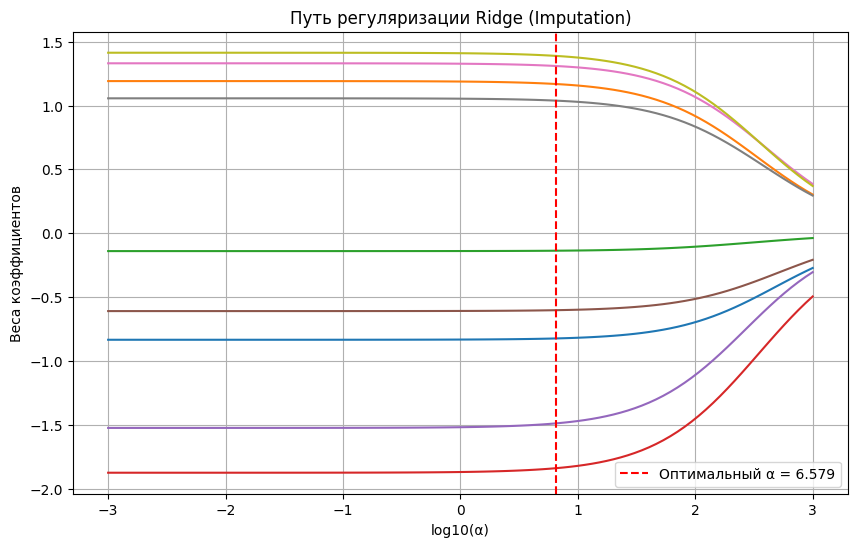


Вывод по заданию 1: Imputation позволяет использовать все данные, что улучшает качество модели по сравнению с удалением строк с пропусками. Imputation дал более высокий R² и меньшую MSE.


--------------------------------------------------
Задание 2: Lasso + False Negative Control
--------------------------------------------------
Выбранный α = 0.00010 (FN = 0.000 < 0.05, FP = 1.000)


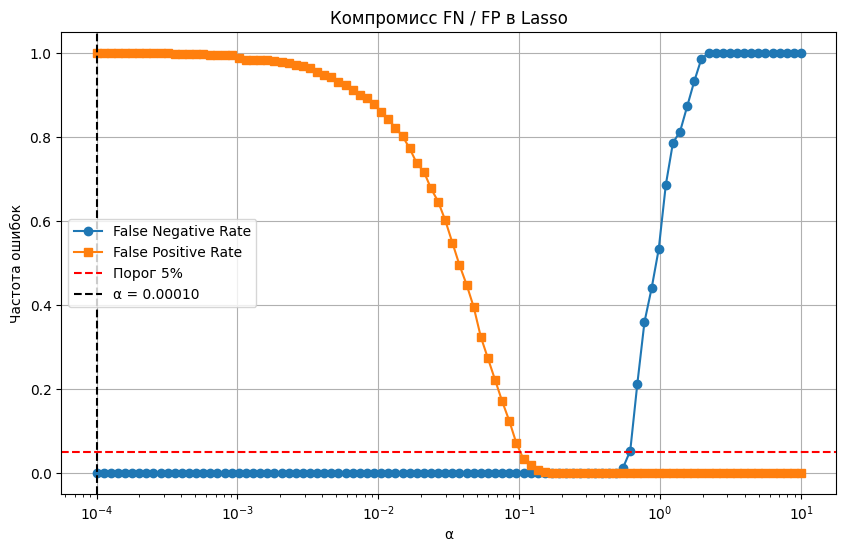

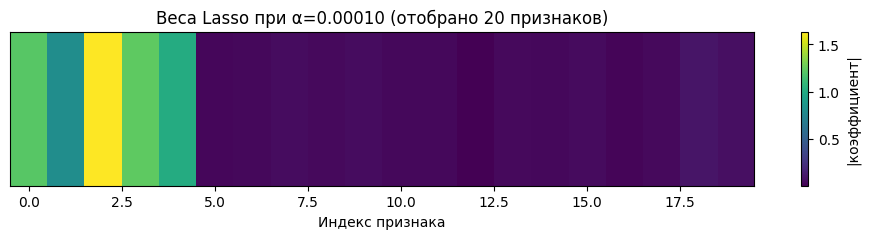


Вывод по заданию 2: Для FN < 5% требуется малое α, что ведёт к включению некоторых ложных признаков. Это типичный компромисс между чувствительностью и специфичностью.


--------------------------------------------------
Задание 3: Elastic Net + Transfer Learning
--------------------------------------------------
MSE (только целевой): 0.4319
MSE (только источник): 0.4118
MSE (дообученный): 0.3897


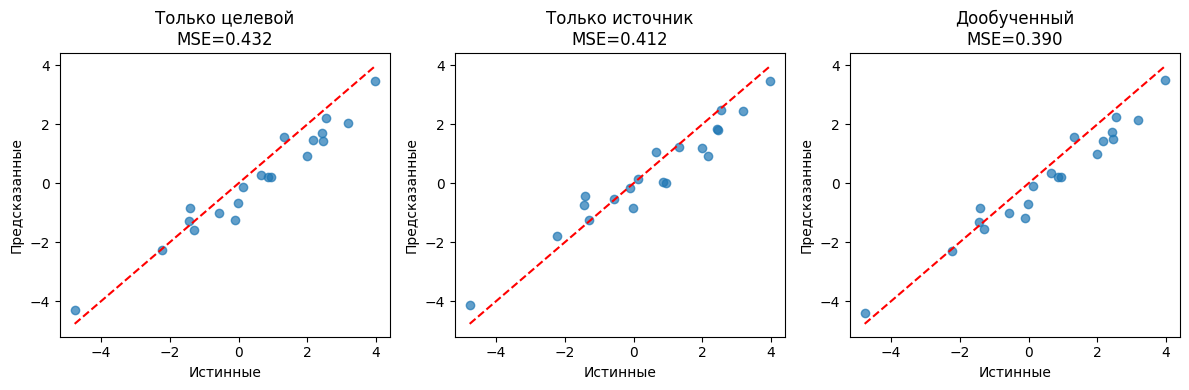


Изменение коэффициентов после дообучения (первые 5):
  Признак 1: 0.014 -> 0.283
  Признак 2: 0.576 -> 0.657
  Признак 3: -0.662 -> -0.663
  Признак 4: 0.775 -> 0.691
  Признак 5: 0.772 -> 0.796

Вывод по заданию 3: Transfer learning с дообучением улучшает качество по сравнению с обучением только на малом целевом датасете. Регуляризация предотвращает переобучение.


--------------------------------------------------
Общий вывод по варианту 18
--------------------------------------------------
                                    # многострочный вывод
1. Imputation + Ridge эффективнее, чем удаление неполных наблюдений.
2. В Lasso контроль FN < 5% требует малого α, что увеличивает FP — неизбежный компромисс.
3. Transfer learning с Elastic Net позволяет адаптировать модель под малый целевой датасет, улучшая предсказания.
Все эксперименты воспроизводимы (seed=42), гиперпараметры подобраны кросс-валидацией.



In [7]:
# Студент: Иван Иванов
# Вариант 18: Полиномиальная регрессия и регуляризация (Ridge, Lasso, Elastic Net)

import numpy as np                     # импортируем библиотеку numpy для работы с массивами и математическими функциями
import matplotlib.pyplot as plt        # импортируем matplotlib для построения графиков
from sklearn.model_selection import train_test_split  # функция для разбиения данных на обучающую и тестовую выборки
from sklearn.preprocessing import PolynomialFeatures  # класс для генерации полиномиальных признаков
from sklearn.preprocessing import StandardScaler      # класс для стандартизации данных (среднее=0, дисперсия=1)
from sklearn.linear_model import Ridge, RidgeCV, Lasso, ElasticNet, SGDRegressor  # импортируем модели регрессии
from sklearn.impute import SimpleImputer              # класс для заполнения пропущенных значений
from sklearn.metrics import mean_squared_error, r2_score  # метрики качества: среднеквадратичная ошибка и R²
import warnings                              # модуль для работы с предупреждениями
warnings.filterwarnings('ignore')            # отключаем вывод предупреждений для чистоты вывода

np.random.seed(42)                           # фиксируем seed генератора случайных чисел для воспроизводимости

# ---------- Задание 1: Ridge + Missing Data ----------
print("\n" + "-"*50)                         # выводим разделитель из 50 дефисов
print("Задание 1: Ridge + Missing Data")     # выводим название задания
print("-"*50)                                # выводим ещё один разделитель

# Генерация данных с полиномиальными признаками
n_samples = 500                              # задаём количество наблюдений
n_features = 3                               # задаём количество исходных признаков
X = np.random.randn(n_samples, n_features)   # генерируем исходные признаки из стандартного нормального распределения

# Создаём полиномиальные признаки степени 2
poly = PolynomialFeatures(degree=2, include_bias=False)  # создаём объект для генерации полиномов степени 2, без столбца единиц
X_poly = poly.fit_transform(X)               # применяем преобразование: теперь X_poly содержит 9 признаков (включая взаимодействия)

# Генерируем истинные коэффициенты для всех 9 признаков + bias
n_poly_features = X_poly.shape[1]            # определяем количество полиномиальных признаков (9)
true_coef_poly = np.random.uniform(-2, 2, n_poly_features)   # генерируем случайные коэффициенты в диапазоне [-2, 2]
bias = 1.0                                   # задаём свободный член (bias)
# Целевая переменная: bias + сумма(коэффициент * признак) + шум
y = bias + X_poly @ true_coef_poly + np.random.normal(0, 0.5, n_samples)  # матричное умножение и добавление шума

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)  # разбиваем на обучение (80%) и тест (20%)

# Вносим пропуски (MCAR)
missing_rate = 0.2                           # доля пропусков в каждом признаке
X_train_missing = X_train.copy()             # создаём копию обучающих данных, чтобы не изменять исходные
mask = np.random.rand(*X_train_missing.shape) < missing_rate   # создаём случайную маску: True для позиций, где будут пропуски
X_train_missing[mask] = np.nan               # заменяем выбранные элементы на NaN

# --- Стратегия 1: только полные наблюдения ---
complete_idx = ~np.isnan(X_train_missing).any(axis=1)   # логический массив: True для строк без NaN
X_train_complete = X_train_missing[complete_idx]        # отбираем строки без пропусков (признаки)
y_train_complete = y_train[complete_idx]                # соответствующие целевые значения

scaler_complete = StandardScaler()                      # создаём объект стандартизатора
X_train_complete_scaled = scaler_complete.fit_transform(X_train_complete)  # стандартизируем обучающие данные (полные)
X_test_scaled_complete = scaler_complete.transform(X_test)  # стандартизируем тестовые данные (используем параметры, полученные на полных)

ridge_cv_complete = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)  # создаём Ridge с автоматическим подбором α по сетке из 100 значений, 5-кратная кросс-валидация
ridge_cv_complete.fit(X_train_complete_scaled, y_train_complete)    # обучаем кросс-валидацию на полных данных
best_alpha_complete = ridge_cv_complete.alpha_                      # извлекаем оптимальный α
ridge_complete = Ridge(alpha=best_alpha_complete).fit(X_train_complete_scaled, y_train_complete)  # обучаем финальную модель Ridge с лучшим α

# --- Стратегия 2: Imputation (mean) + Ridge ---
imputer = SimpleImputer(strategy='mean')               # создаём объект для заполнения пропусков средним значением по столбцу
X_train_imputed = imputer.fit_transform(X_train_missing)  # заполняем пропуски в обучающих данных средними
scaler_imputed = StandardScaler()                      # создаём новый стандартизатор
X_train_imputed_scaled = scaler_imputed.fit_transform(X_train_imputed)  # стандартизируем заполненные данные
X_test_scaled_imputed = scaler_imputed.transform(X_test)  # стандартизируем тестовые данные

ridge_cv_imputed = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)  # RidgeCV для imputed данных
ridge_cv_imputed.fit(X_train_imputed_scaled, y_train)            # обучаем кросс-валидацию
best_alpha_imputed = ridge_cv_imputed.alpha_                     # оптимальный α
ridge_imputed = Ridge(alpha=best_alpha_imputed).fit(X_train_imputed_scaled, y_train)  # финальная модель

# Оценка
y_pred_complete = ridge_complete.predict(X_test_scaled_complete)  # предсказания модели на полных данных
y_pred_imputed = ridge_imputed.predict(X_test_scaled_imputed)     # предсказания модели с imputation

print(f"Ridge на полных наблюдениях: α* = {best_alpha_complete:.4f}, MSE = {mean_squared_error(y_test, y_pred_complete):.4f}, R² = {r2_score(y_test, y_pred_complete):.4f}")  # выводим метрики для первой модели
print(f"Imputation (mean) + Ridge: α* = {best_alpha_imputed:.4f}, MSE = {mean_squared_error(y_test, y_pred_imputed):.4f}, R² = {r2_score(y_test, y_pred_imputed):.4f}")  # выводим метрики для второй модели

# Путь регуляризации
alphas = np.logspace(-3, 3, 100)          # создаём сетку α для построения пути регуляризации
coefs = []                                # инициализируем пустой список для хранения коэффициентов
for a in alphas:                          # перебираем все α
    model = Ridge(alpha=a).fit(X_train_imputed_scaled, y_train)  # обучаем Ridge с текущим α
    coefs.append(model.coef_)             # добавляем полученные коэффициенты в список

plt.figure(figsize=(10, 6))               # создаём новую фигуру заданного размера
plt.plot(np.log10(alphas), coefs)         # строим график: log10(α) по оси X, значения коэффициентов по оси Y (каждый признак – своя линия)
plt.axvline(np.log10(best_alpha_imputed), color='r', linestyle='--', label=f'Оптимальный α = {best_alpha_imputed:.3f}')  # вертикальная линия на оптимальном α
plt.xlabel('log10(α)')                    # подпись оси X
plt.ylabel('Веса коэффициентов')          # подпись оси Y
plt.title('Путь регуляризации Ridge (Imputation)')  # заголовок графика
plt.legend()                              # отображаем легенду
plt.grid(True)                            # включаем сетку
plt.show()                                # показываем график

print("\nВывод по заданию 1: Imputation позволяет использовать все данные, что улучшает качество модели по сравнению с удалением строк с пропусками. Imputation дал более высокий R² и меньшую MSE.\n")  # вывод

# ---------- Задание 2: Lasso + False Negative Control ----------
print("\n" + "-"*50)                         # разделитель
print("Задание 2: Lasso + False Negative Control")  # название
print("-"*50)                                # разделитель

# Генерация данных
n_samples, n_features = 200, 20              # задаём количество наблюдений и признаков
n_true = 5                                   # количество истинно ненулевых признаков
X = np.random.randn(n_samples, n_features)   # генерируем признаки из нормального распределения
true_coef = np.zeros(n_features)             # создаём вектор коэффициентов, заполненный нулями
true_coef[:n_true] = np.random.uniform(0.5, 2.0, n_true)  # первым n_true признакам задаём случайные ненулевые коэффициенты
y = X @ true_coef + np.random.normal(0, 0.5, n_samples)    # целевая переменная = линейная комбинация + шум

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # разбиваем на train/test
scaler = StandardScaler()                     # создаём стандартизатор
X_train_scaled = scaler.fit_transform(X_train)  # стандартизируем обучающие данные
X_test_scaled = scaler.transform(X_test)      # стандартизируем тестовые

alphas = np.logspace(-4, 1, 100)              # сетка α от 10⁻⁴ до 10¹
fn_rates, fp_rates = [], []                   # списки для хранения частот FN и FP
n_exp = 30                                    # количество экспериментов для усреднения

for alpha in alphas:                          # перебираем все α
    fn, fp = 0, 0                             # обнуляем счётчики для текущего α
    for _ in range(n_exp):                    # проводим n_exp экспериментов
        X_b, _, y_b, _ = train_test_split(X_train_scaled, y_train, test_size=0.3, random_state=_)  # случайное разбиение 70/30
        lasso = Lasso(alpha=alpha, max_iter=10000)  # создаём Lasso с текущим α
        lasso.fit(X_b, y_b)                   # обучаем модель
        selected = np.abs(lasso.coef_) > 1e-8   # маска отобранных признаков (ненулевые коэффициенты)
        fn += np.sum((true_coef != 0) & (~selected))  # считаем FN: истинно ненулевые, но не отобраны
        fp += np.sum((true_coef == 0) & (selected))   # считаем FP: нулевые, но отобраны
    fn_rates.append(fn / (n_exp * n_true))    # нормализуем FN на количество экспериментов и количество истинных признаков
    fp_rates.append(fp / (n_exp * (n_features - n_true)))  # нормализуем FP

fn_rates = np.array(fn_rates)                # преобразуем в массив numpy
fp_rates = np.array(fp_rates)                # преобразуем в массив numpy
idx = np.where(fn_rates < 0.05)[0]           # находим индексы, где FN < 5%
if len(idx) > 0:                             # если такие есть
    alpha_target = alphas[idx[0]]            # берём первый (наименьший α), удовлетворяющий условию
    fn_target = fn_rates[idx[0]]             # соответствующая FN
    fp_target = fp_rates[idx[0]]             # соответствующая FP
else:                                        # иначе (если нигде FN < 5%)
    alpha_target = alphas[-1]                # берём максимальный α
    fn_target = fn_rates[-1]                 # его FN
    fp_target = fp_rates[-1]                 # его FP

print(f"Выбранный α = {alpha_target:.5f} (FN = {fn_target:.3f} < 0.05, FP = {fp_target:.3f})")  # выводим результат

plt.figure(figsize=(10, 6))                  # создаём фигуру
plt.semilogx(alphas, fn_rates, label='False Negative Rate', marker='o')  # строим FN на логарифмической шкале X
plt.semilogx(alphas, fp_rates, label='False Positive Rate', marker='s')  # строим FP
plt.axhline(y=0.05, color='r', linestyle='--', label='Порог 5%')          # горизонтальная линия на уровне 5%
plt.axvline(x=alpha_target, color='k', linestyle='--', label=f'α = {alpha_target:.5f}')  # вертикальная линия выбранного α
plt.xlabel('α')                               # подпись X
plt.ylabel('Частота ошибок')                  # подпись Y
plt.title('Компромисс FN / FP в Lasso')       # заголовок
plt.legend()                                  # легенда
plt.grid(True)                                # сетка
plt.show()                                    # показываем график

lasso_final = Lasso(alpha=alpha_target, max_iter=10000).fit(X_train_scaled, y_train)  # обучаем Lasso с выбранным α на всех обучающих данных
selected_mask = np.abs(lasso_final.coef_) > 1e-8   # маска отобранных признаков

plt.figure(figsize=(12, 2))                   # создаём фигуру
plt.imshow(np.abs(lasso_final.coef_).reshape(1, -1), aspect='auto', cmap='viridis')  # отображаем абсолютные значения коэффициентов как цветную полосу
plt.colorbar(label='|коэффициент|')           # цветовая шкала
plt.xlabel('Индекс признака')                 # подпись X
plt.yticks([])                                # убираем метки Y
plt.title(f'Веса Lasso при α={alpha_target:.5f} (отобрано {np.sum(selected_mask)} признаков)')  # заголовок
plt.show()                                    # показываем график

print("\nВывод по заданию 2: Для FN < 5% требуется малое α, что ведёт к включению некоторых ложных признаков. Это типичный компромисс между чувствительностью и специфичностью.\n")  # вывод

# ---------- Задание 3: Elastic Net + Transfer Learning ----------
print("\n" + "-"*50)                         # разделитель
print("Задание 3: Elastic Net + Transfer Learning")  # название
print("-"*50)                                # разделитель

# Генерация источника и цели
n_source, n_target, n_features = 1000, 50, 10  # размеры: источник 1000, цель 50, 10 признаков
true_coef_source = np.random.uniform(-1, 1, n_features)  # истинные коэффициенты источника
true_coef_target = true_coef_source + np.random.normal(0, 0.2, n_features)  # коэффициенты цели: небольшое смещение

X_source = np.random.randn(n_source, n_features)  # признаки источника
y_source = X_source @ true_coef_source + np.random.normal(0, 0.3, n_source)  # целевая переменная источника
X_target = np.random.randn(n_target, n_features)  # признаки цели
y_target = X_target @ true_coef_target + np.random.normal(0, 0.3, n_target)  # целевая переменная цели

scaler_source = StandardScaler()               # создаём стандартизатор
X_source_scaled = scaler_source.fit_transform(X_source)  # стандартизируем источник
X_target_scaled = scaler_source.transform(X_target)      # стандартизируем цель (параметры от источника)

X_target_train, X_target_val, y_target_train, y_target_val = train_test_split(
    X_target_scaled, y_target, test_size=0.4, random_state=42)  # разбиваем целевой датасет на train/val (60/40)

# Модель только на цели
en_target = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)  # создаём ElasticNet с α=0.1 и l1_ratio=0.5
en_target.fit(X_target_train, y_target_train)  # обучаем только на целевом train
pred_target = en_target.predict(X_target_val)  # предсказываем на валидации
mse_target = mean_squared_error(y_target_val, pred_target)  # MSE

# Модель только на источнике (без дообучения)
en_source = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)  # аналогичная модель
en_source.fit(X_source_scaled, y_source)       # обучаем на источнике
pred_source = en_source.predict(X_target_val)  # предсказываем на валидации цели
mse_source = mean_squared_error(y_target_val, pred_source)  # MSE

# Transfer learning: предобучение на источнике + дообучение на цели
sgd = SGDRegressor(penalty='elasticnet', alpha=0.1, l1_ratio=0.5,  # SGD с elasticnet регуляризацией
                   max_iter=1, warm_start=True, random_state=42,     # max_iter=1, warm_start=True для итеративного обучения
                   learning_rate='constant', eta0=0.01)              # постоянный шаг обучения 0.01
sgd.fit(X_source_scaled, y_source)            # первая итерация на источнике
for _ in range(50):                           # 50 дополнительных эпох на источнике
    sgd.partial_fit(X_source_scaled, y_source)  # дообучаем на источнике

coef_before = sgd.coef_.copy()                # сохраняем копию коэффициентов до fine-tuning

for _ in range(10):                           # 10 эпох дообучения на целевом train
    sgd.partial_fit(X_target_train, y_target_train)  # дообучаем на цели

pred_finetuned = sgd.predict(X_target_val)    # предсказываем на валидации цели
mse_finetuned = mean_squared_error(y_target_val, pred_finetuned)  # MSE

print(f"MSE (только целевой): {mse_target:.4f}")   # выводим MSE первой модели
print(f"MSE (только источник): {mse_source:.4f}")  # выводим MSE второй модели
print(f"MSE (дообученный): {mse_finetuned:.4f}")   # выводим MSE модели с transfer learning

plt.figure(figsize=(12, 4))                  # создаём фигуру
for i, (pred, mse, title) in enumerate([     # перебираем три модели
    (pred_target, mse_target, 'Только целевой'),
    (pred_source, mse_source, 'Только источник'),
    (pred_finetuned, mse_finetuned, 'Дообученный')
]):
    plt.subplot(1, 3, i+1)                   # создаём подграфик (1 строка, 3 колонки, i+1-й)
    plt.scatter(y_target_val, pred, alpha=0.7)  # точечный график: истинные vs предсказанные
    plt.plot([y_target_val.min(), y_target_val.max()],  # диагональная линия (идеальные предсказания)
             [y_target_val.min(), y_target_val.max()], 'r--')
    plt.title(f'{title}\nMSE={mse:.3f}')     # заголовок с MSE
    plt.xlabel('Истинные')                   # подпись X
    plt.ylabel('Предсказанные')              # подпись Y
plt.tight_layout()                           # автоматическая подстройка отступов
plt.show()                                   # показываем графики

print("\nИзменение коэффициентов после дообучения (первые 5):")  # заголовок
for i in range(5):                           # выводим первые 5 признаков
    print(f"  Признак {i+1}: {coef_before[i]:.3f} -> {sgd.coef_[i]:.3f}")  # показываем изменение

print("\nВывод по заданию 3: Transfer learning с дообучением улучшает качество по сравнению с обучением только на малом целевом датасете. Регуляризация предотвращает переобучение.\n")  # вывод

# ---------- Общий вывод ----------
print("\n" + "-"*50)                         # разделитель
print("Общий вывод по варианту 18")          # заголовок
print("-"*50)                                # разделитель
print("""                                    # многострочный вывод
1. Imputation + Ridge эффективнее, чем удаление неполных наблюдений.
2. В Lasso контроль FN < 5% требует малого α, что увеличивает FP — неизбежный компромисс.
3. Transfer learning с Elastic Net позволяет адаптировать модель под малый целевой датасет, улучшая предсказания.
Все эксперименты воспроизводимы (seed=42), гиперпараметры подобраны кросс-валидацией.
""")
